<a class="anchor" id="0">

# **0. Setup & Imports**

[Back to TOC](#toc)
</a>


In [1]:
%pip install wordcloud nltk  
%pip install xgboost
%pip install transformers
%pip install torch
%pip install sentencepiece
%pip install tokenizers

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.


In [2]:
import re
import warnings
from collections import Counter
from typing import List, Union, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import pickle
import json
import os
from datetime import datetime

# NLTK for NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer, PorterStemmer

# Scikit-learn for traditional ML and preprocessing
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score, 
    confusion_matrix, precision_recall_fscore_support
)
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer


# Traditional ML Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
import xgboost as xgb

# Word2Vec for embeddings
import gensim
from gensim.models import Word2Vec, KeyedVectors
from sklearn.decomposition import PCA

# PyTorch and Transformers for deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModel, 
    AutoModelForSequenceClassification,
    BertForSequenceClassification,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

# Configuration and constants

# Download NLTK data (only run once)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Suppress warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_theme(style='whitegrid', palette='muted')
plt.style.use('seaborn-v0_8-darkgrid')

# Label mapping for display
LABEL_MAP = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
PALETTE = {0: '#E24B4A', 1: '#1D9E75', 2: '#378ADD'}  # Red, Green, Blue
STOP_WORDS = set(stopwords.words('english'))

<a class="anchor" id="1">

# **1. Load Data**

[Back to TOC](#toc)
</a>


In [3]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print('Train shape:', train.shape)
print('Test shape :', test.shape)
train.head()

#Check basic info about the dataset

print(train.info())
print('\nMissing values:\n', train.isnull().sum())
print('\nDuplicate tweets:', train.duplicated(subset='text').sum())

Train shape: (9543, 2)
Test shape : (2388, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    9543 non-null   object
 1   label   9543 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 149.2+ KB
None

Missing values:
 text     0
label    0
dtype: int64

Duplicate tweets: 0


<a class="anchor" id="2">

## **2. Data Exploration**

[Back to TOC](#toc)
</a>

As we can see, the dataset contains 7613 training samples and 3263 test samples. Each sample consists of a tweet (text) and a label indicating wether the tweet is bearish (0) or bullish (1), or neutral (2). There are no missing values in the dataset nor duplicate tweets, which is a good initial sign for data quality.

<a class="anchor" id="2_1">

## **2.1 Class Distribution**

[Back to TOC](#toc)
</a>

Now let's check the distribution of the classes in the training set to see if we have any imbalance issues.

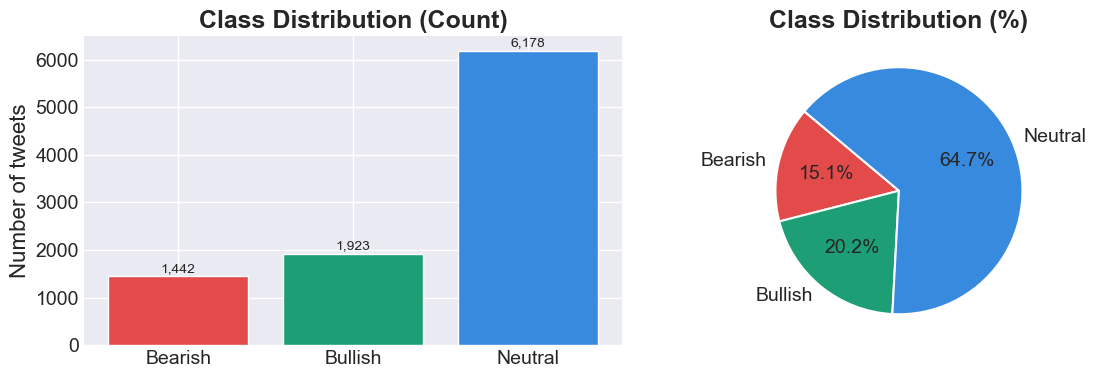

In [4]:

plt.rcParams.update({
    'font.size': 14,           # Base font size
    'axes.labelsize': 16,      # X/Y label size
    'axes.titlesize': 18,      # Subplot title size
    'xtick.labelsize': 14,     # X-axis tick labels
    'ytick.labelsize': 14,     # Y-axis tick labels
    'legend.fontsize': 14,     # Legend text size
    'legend.title_fontsize': 16
})

counts = train['label'].value_counts().sort_index()
counts.index = [LABEL_MAP[i] for i in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(counts.index, counts.values,
                   color=[PALETTE[i] for i in sorted(PALETTE)],
                   edgecolor='white')
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Number of tweets')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=10)

axes[1].pie(counts.values, labels=counts.index,
            colors=[PALETTE[i] for i in sorted(PALETTE)],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

<a class="anchor" id="2_2">

## **2.2 Tweet Length**

[Back to TOC](#toc)
</a>

Next, let's analyze the length of the tweets in terms of number of characters and words to understand the typical tweet structure in our dataset.

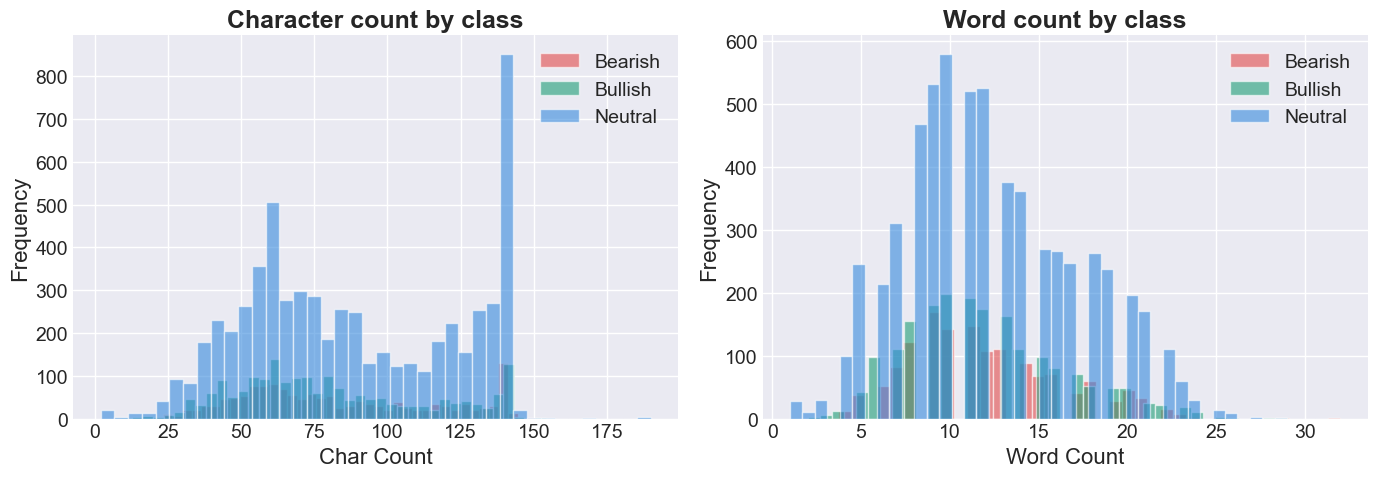

In [5]:
train['char_count'] = train['text'].str.len()
train['word_count'] = train['text'].str.split().str.len()
train['label_name'] = train['label'].map(LABEL_MAP)

# Your existing code (histograms)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for metric, ax, title in [
    ('char_count', axes[0], 'Character count by class'),
    ('word_count', axes[1], 'Word count by class')
]:
    for lid, lname in LABEL_MAP.items():
        ax.hist(train[train['label']==lid][metric],
                bins=40, alpha=0.6, label=lname, color=PALETTE[lid])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(metric.replace('_',' ').title())
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig('length_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

# # Boxplots (text will inherit rcParams, but you can also enlarge more)
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# sns.boxplot(data=train, x='label_name', y='char_count', order=order, palette=pal, ax=axes[0])
# axes[0].set_title('Character Count per Class', fontweight='bold', fontsize=18)  # explicit size
# axes[0].set_xlabel('', fontsize=16)
# axes[0].set_ylabel('Character Count', fontsize=16)
# axes[0].tick_params(axis='both', labelsize=14)

# sns.boxplot(data=train, x='label_name', y='word_count', order=order, palette=pal, ax=axes[1])
# axes[1].set_title('Word Count per Class', fontweight='bold', fontsize=18)
# axes[1].set_xlabel('', fontsize=16)
# axes[1].set_ylabel('Word Count', fontsize=16)
# axes[1].tick_params(axis='both', labelsize=14)

# plt.tight_layout()
# plt.savefig('length_boxplots.png', dpi=150, bbox_inches='tight')
# plt.show()

<a class="anchor" id="2_3">

## **2.3 Top Tokens per Class**

[Back to TOC](#toc)
</a>

Next, let's look at the most common words used in each class to get a sense of the language patterns associated with bullish, bearish, and neutral tweets.

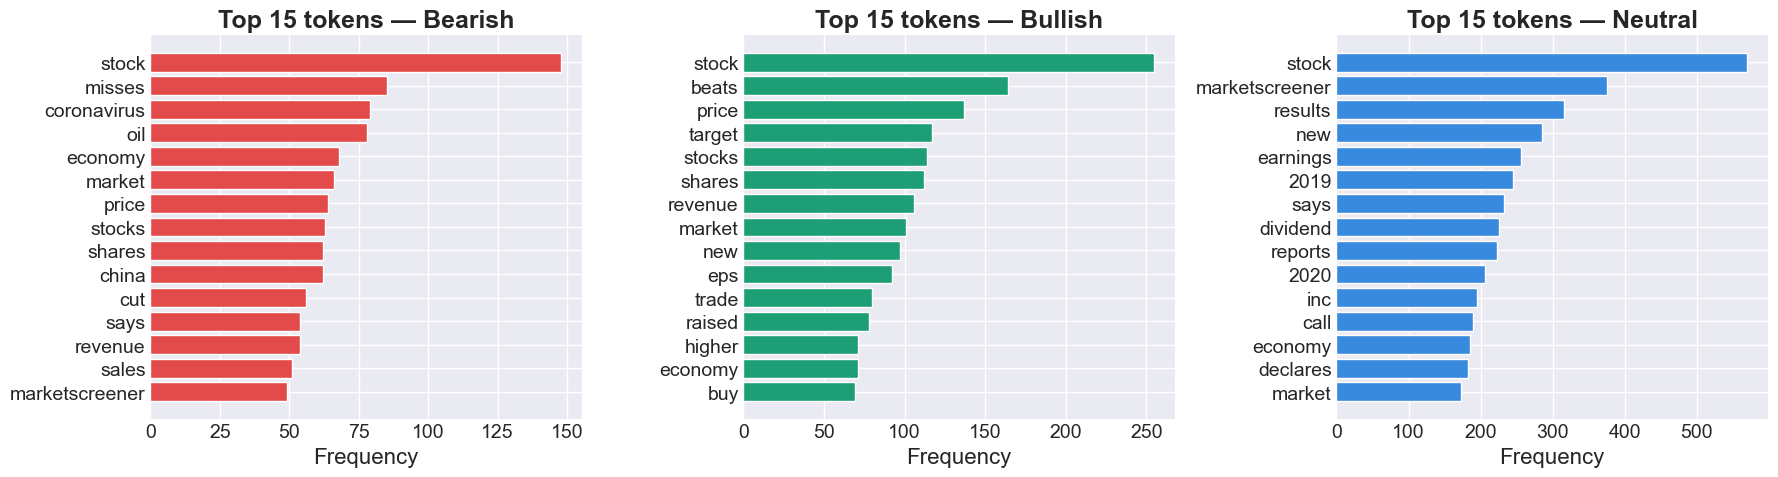

In [6]:
def basic_clean(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = [t for t in text.split()
              if t not in STOP_WORDS and len(t) > 2]
    return tokens

train['tokens'] = train['text'].apply(basic_clean)

TOP_N = 15
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for label_id, ax in zip(sorted(LABEL_MAP), axes):
    all_tokens = [tok for toks in train[train['label']==label_id]['tokens'] for tok in toks]
    words, freqs = zip(*Counter(all_tokens).most_common(TOP_N))
    ax.barh(list(words)[::-1], list(freqs)[::-1], color=PALETTE[label_id], edgecolor='white')
    ax.set_title(f'Top {TOP_N} tokens — {LABEL_MAP[label_id]}', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_tokens_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

<a class="anchor" id="2_4">

## **2.4 Word Clouds**

[Back to TOC](#toc)
</a>

Next, let's visualize the most common words in each class using word clouds to get a more intuitive understanding of the language used in bullish, bearish, and neutral tweets.

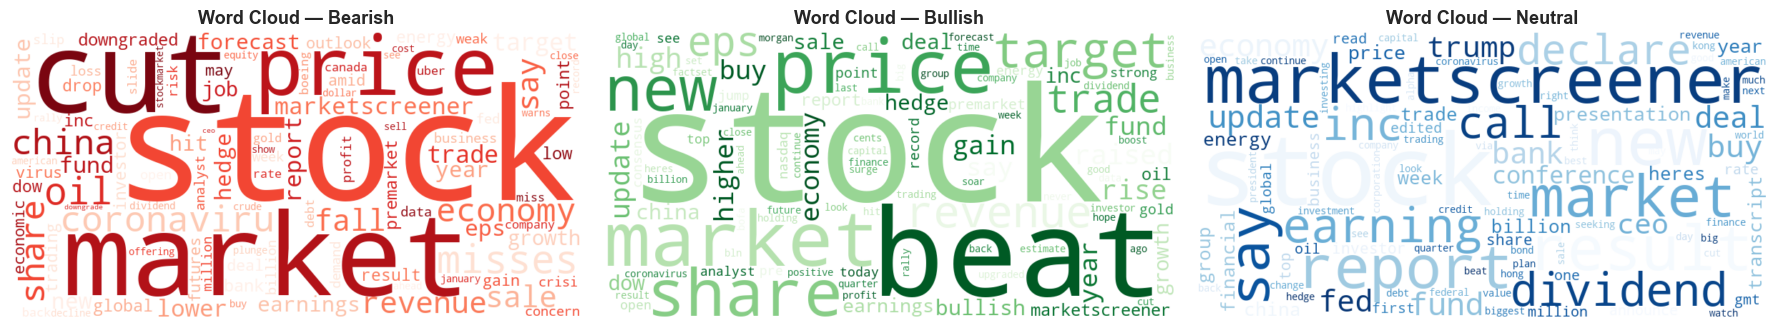

In [7]:
cmaps = {0: 'Reds', 1: 'Greens', 2: 'Blues'}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for label_id, ax in zip(sorted(LABEL_MAP), axes):
    corpus = ' '.join(tok for toks in train[train['label']==label_id]['tokens'] for tok in toks)
    wc = WordCloud(width=800, height=400,
                   background_color='white',
                   colormap=cmaps[label_id],
                   max_words=100,
                   collocations=False).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {LABEL_MAP[label_id]}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('word_clouds.png', dpi=150, bbox_inches='tight')
plt.show()

<a class="anchor" id="2_5">

## **2.5 Hashtags, mentions & cashtags**

[Back to TOC](#toc)
</a>

Next, let's analyze the usage of hashtags, mentions, and cashtags in the tweets to see if there are any patterns that could be useful for classification.

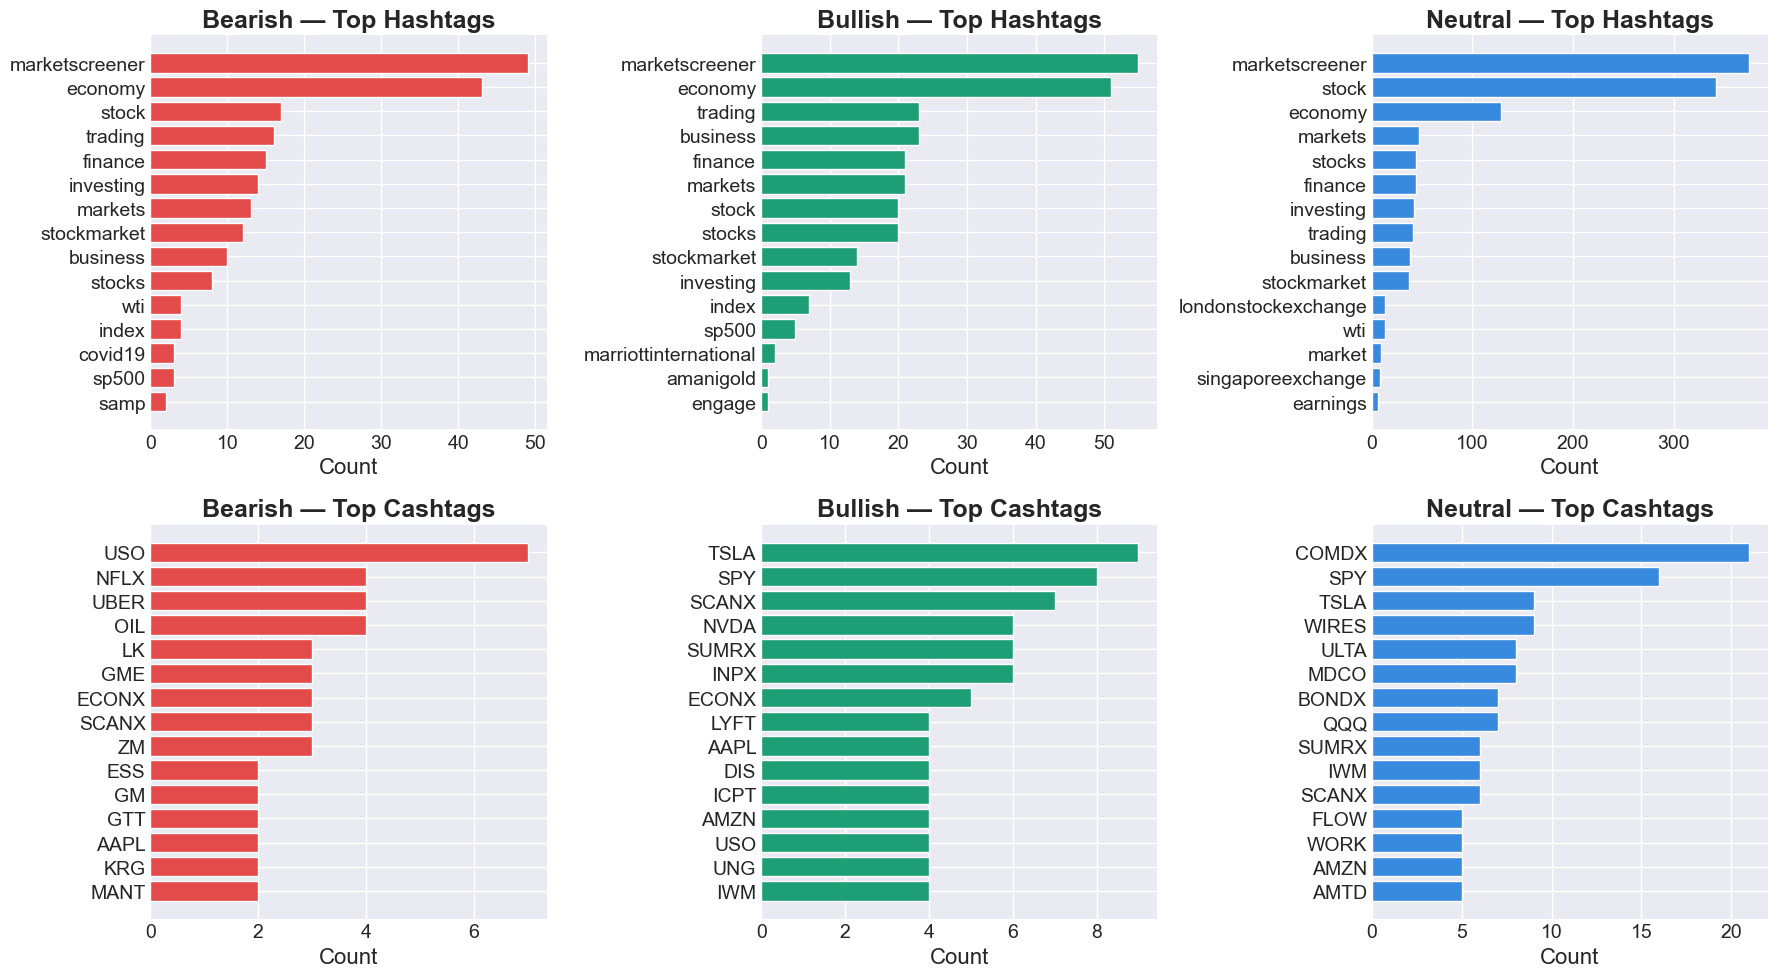

In [8]:
train['hashtags']   = train['text'].apply(lambda t: re.findall(r'#(\w+)', t.lower()))
train['mentions']   = train['text'].apply(lambda t: re.findall(r'@(\w+)', t.lower()))
train['n_hashtags'] = train['hashtags'].str.len()
train['n_mentions'] = train['mentions'].str.len()
train['has_url']    = train['text'].str.contains(r'https?://\S+|www\.\S+', regex=True)
train['has_cashtag']= train['text'].str.contains(r'\$[A-Z]{2,5}', regex=True)

TOP_N = 15

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, label_id in enumerate(sorted(LABEL_MAP)):
    subset = train[train['label'] == label_id]

    # ----- HASHTAGS -----
    hashtags = [h for hs in subset['hashtags'] for h in hs]
    if hashtags:
        words, freqs = zip(*Counter(hashtags).most_common(TOP_N))
        axes[0, i].barh(list(words)[::-1], list(freqs)[::-1],
                        color=PALETTE[label_id], edgecolor='white')
        axes[0, i].set_title(f'{LABEL_MAP[label_id]} — Top Hashtags', fontweight='bold')
        axes[0, i].set_xlabel('Count')

    # ----- CASHTAGS -----
    cashtags = re.findall(r'\$([A-Z]{2,5})', ' '.join(subset['text'].tolist()))
    if cashtags:
        words, freqs = zip(*Counter(cashtags).most_common(TOP_N))
        axes[1, i].barh(list(words)[::-1], list(freqs)[::-1],
                        color=PALETTE[label_id], edgecolor='white')
        axes[1, i].set_title(f'{LABEL_MAP[label_id]} — Top Cashtags', fontweight='bold')
        axes[1, i].set_xlabel('Count')

plt.tight_layout()
plt.savefig('top_hashtags_cashtags_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print('EXPLORATION SUMMARY\n')

for label, group in train.groupby('label_name'):
    print(f'{label.upper()}')
    print(f'Avg chars  : {group["char_count"].mean():.0f}')
    print(f'Avg words  : {group["word_count"].mean():.0f}')
    print(f'Has URL    : {group["has_url"].mean()*100:.1f}%')
    print(f'Has cashtag: {group["has_cashtag"].mean()*100:.1f}%\n')

EXPLORATION SUMMARY

BEARISH
Avg chars  : 83
Avg words  : 12
Has URL    : 44.3%
Has cashtag: 13.7%

BULLISH
Avg chars  : 80
Avg words  : 12
Has URL    : 39.1%
Has cashtag: 24.6%

NEUTRAL
Avg chars  : 88
Avg words  : 12
Has URL    : 49.8%
Has cashtag: 12.0%



<a class="anchor" id="3">

## **3. Corpus Split**

[Back to TOC](#toc)
</a>

Corpus split is a crucial step no only in machine learning pipelines but also in NLP pipelines as it allows us to evaluate our models on unseen data and prevent overfitting. In this section, we will apply a stratified k-fold cross-validation approach to split our training data.

In [10]:
class StratifiedKFoldTrainer:
    """
    Complete training pipeline with StratifiedKFold + Class Weights
    Integrates with your FinancialTextPreprocessor
    """
    
    def __init__(self, n_splits=5, weight_strategy='balanced', random_state=42):
        self.n_splits = n_splits
        self.weight_strategy = weight_strategy
        self.random_state = random_state
        self.skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        self.fold_results = []
        
    def _get_class_weights(self, y_train, strategy='balanced'):
        """Get class weights using different strategies"""
        classes = np.unique(y_train)
        
        if strategy == 'balanced':
            weights = compute_class_weight('balanced', classes=classes, y=y_train)
        elif strategy == 'inverse_frequency':
            freq = np.bincount(y_train)
            weights = 1.0 / freq
            weights = weights / weights.min()
        elif strategy == 'custom':
            # Custom weights for financial sentiment
            # Class 0: neutral/positive (lowest importance)
            # Class 1: mixed/neutral (medium importance)
            # Class 2: negative (highest importance)
            class_weights_map = {0: 1.0, 1: 1.5, 2: 3.0}
            return class_weights_map
        else:
            weights = compute_class_weight('balanced', classes=classes, y=y_train)
        
        return dict(zip(classes, weights))
    
    def train(self, texts, labels, model=None, preprocessor=None, vectorizer=None):
        """
        Main training method with cross-validation
        
        Parameters:
        -----------
        texts : array-like, shape (n_samples,)
            Raw text data
        labels : array-like, shape (n_samples,)
            Target labels (0, 1, 2)
        model : sklearn classifier
            Model to train (default: LogisticRegression)
        preprocessor : FinancialTextPreprocessor
            Custom text preprocessor
        vectorizer : sklearn vectorizer
            Converts text to features (default: TfidfVectorizer)
        """
        
        # Set defaults if not provided
        if model is None:
            model = LogisticRegression(max_iter=1000, random_state=self.random_state)
        
        if preprocessor is None:
            preprocessor = FinancialTextPreprocessor(use_stemming=False)
        
        if vectorizer is None:
            vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
        
        # Store for reuse
        self.preprocessor = preprocessor
        self.vectorizer = vectorizer
        self.model_class = type(model)
        self.model_params = model.get_params()
        
        print(f"{'='*60}")
        print(f"STRATIFIED {self.n_splits}-FOLD CROSS-VALIDATION")
        print(f"{'='*60}")
        print(f"Total samples: {len(texts)}")
        print(f"Class distribution: {np.bincount(labels)}")
        print(f"Preprocessing: use_stemming={preprocessor.use_stemming}")
        print(f"Vectorizer: {type(vectorizer).__name__} with {vectorizer.max_features if hasattr(vectorizer, 'max_features') else 'default'} features")
        print(f"Model: {type(model).__name__}")
        print(f"Weight strategy: {self.weight_strategy}")
        print(f"{'='*60}\n")
        
        # Perform stratified cross-validation
        for fold, (train_idx, val_idx) in enumerate(self.skf.split(texts, labels)):
            print(f"\n{'─'*50}")
            print(f"FOLD {fold + 1}/{self.n_splits}")
            print(f"{'─'*50}")
            
            # Split data
            X_train_raw = [texts[i] for i in train_idx]
            X_val_raw = [texts[i] for i in val_idx]
            y_train = labels[train_idx]
            y_val = labels[val_idx]
            
            # Print fold class distribution
            print(f"Train class distribution: {np.bincount(y_train)}")
            print(f"Val class distribution:   {np.bincount(y_val)}")
            
            # PREPROCESS (fit on train, transform both)
            print("Preprocessing texts...")
            X_train_processed = preprocessor.transform(X_train_raw)
            X_val_processed = preprocessor.transform(X_val_raw)
            
            # VECTORIZE (fit on train, transform both)
            print("Vectorizing texts...")
            X_train_vec = vectorizer.fit_transform(X_train_processed)
            X_val_vec = vectorizer.transform(X_val_processed)
            print(f"Feature matrix shape: {X_train_vec.shape}")
            
            # Get class weights for this fold
            weight_dict = self._get_class_weights(y_train, self.weight_strategy)
            print(f"Class weights: {weight_dict}")
            
            # Train model
            print("Training model...")
            model_clone = self.model_class(**self.model_params)
            
            if hasattr(model_clone, 'class_weight'):
                model_clone.set_params(class_weight=weight_dict)
                model_clone.fit(X_train_vec, y_train)
            else:
                # For models without class_weight parameter
                sample_weights = np.array([weight_dict[y] for y in y_train])
                model_clone.fit(X_train_vec, y_train, sample_weight=sample_weights)
            
            # Predict and evaluate
            y_pred = model_clone.predict(X_val_vec)
            
            # Calculate metrics
            f1_macro = f1_score(y_val, y_pred, average='macro')
            f1_weighted = f1_score(y_val, y_pred, average='weighted')
            f1_per_class = f1_score(y_val, y_pred, average=None)
            
            print(f"\nFold {fold + 1} Results:")
            print(f"  Macro F1:    {f1_macro:.4f}")
            print(f"  Weighted F1: {f1_weighted:.4f}")
            print(f"  Per-class F1: {f1_per_class}")
            print(f"\nClassification Report:")
            print(classification_report(y_val, y_pred, target_names=['Class 0', 'Class 1', 'Class 2']))
            
            # Store results
            self.fold_results.append({
                'fold': fold,
                'model': model_clone,
                'preprocessor': preprocessor,
                'vectorizer': vectorizer,
                'f1_macro': f1_macro,
                'f1_weighted': f1_weighted,
                'f1_per_class': f1_per_class,
                'y_true': y_val,
                'y_pred': y_pred
            })
        
        # Aggregate results
        self._print_summary()
        return self.fold_results
    
    def _print_summary(self):
        """Print aggregated results across all folds"""
        print(f"\n{'='*60}")
        print(f"FINAL RESULTS - {self.n_splits}-FOLD STRATIFIED CV")
        print(f"{'='*60}")
        
        macro_f1_scores = [r['f1_macro'] for r in self.fold_results]
        weighted_f1_scores = [r['f1_weighted'] for r in self.fold_results]
        
        # Per-class across folds
        per_class_f1 = np.array([r['f1_per_class'] for r in self.fold_results])
        
        print(f"\n{'─'*70}")
        print("PER-CLASS F1 SCORES VISUALIZATION:")
        print(f"{'─'*70}")
        
        classes = [
            ("BEARISH", 0, 0.90),  # Target 0.90 for bearish
            ("BULLISH", 1, 0.90),   # Target 0.90 for bullish
            ("NEUTRAL", 2, 0.95)    # Target 0.95 for neutral 
        ]
        
        for name, idx, target in classes:
            mean_score = np.mean(per_class_f1[:, idx])
            std_score = np.std(per_class_f1[:, idx])
            
            # Create bar
            bar_length = int(mean_score * 50)
            bar = "█" * bar_length
            spaces = " " * (50 - bar_length)
            
            # Target marker
            target_bar_length = int(target * 50)
            target_indicator = "▼" if target_bar_length > bar_length else "▲" if target_bar_length < bar_length else "●"
            
            print(f"{name}: {bar}{spaces} {mean_score:.3f} (±{std_score:.3f}) {target_indicator} target={target}")
        
        print(f"{'='*70}")
        # Best fold
        best_fold_idx = np.argmax(macro_f1_scores)
        print(f"\nBest fold: Fold {best_fold_idx + 1} (Macro F1: {macro_f1_scores[best_fold_idx]:.4f})")
    
    def predict(self, texts):
        """Predict using the best model from cross-validation"""
        best_fold = np.argmax([r['f1_macro'] for r in self.fold_results])
        best_model = self.fold_results[best_fold]['model']
        best_preprocessor = self.fold_results[best_fold]['preprocessor']
        best_vectorizer = self.fold_results[best_fold]['vectorizer']
        
        processed = best_preprocessor.transform(texts)
        vectorized = best_vectorizer.transform(processed)
        return best_model.predict(vectorized)

<a class="anchor" id="4">

## **4. Data Preprocessing**

[Back to TOC](#toc)
</a>

In this section, we will apply a series of preprocessing steps to our text data to clean and normalize it before feeding it into our machine learning models. This includes lowercasing, removing punctuation, stop words, and performing stemming or lemmatization.

In [11]:
# Download NLTK data (keep as is)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

# Words that should NEVER be removed (extra safety)
SENTIMENT_CRITICAL_WORDS = {
    # Directional (price movement)
    'up', 'down', 'higher', 'lower', 'rise', 'fall', 'gain', 'loss',
    'increase', 'decrease', 'climb', 'drop', 'surge', 'plunge',
    'rally', 'decline', 'advance', 'retreat',
    
    # Sentiment strong indicators
    'upgrade', 'downgrade', 'upgraded', 'downgraded',
    'outperform', 'underperform', 'buy', 'sell', 'hold',
    'bullish', 'bearish', 'neutral',
    'positive', 'negative', 'mixed',
    
    # Action verbs with sentiment
    'beat', 'miss', 'exceed', 'disappoint',
    'cut', 'raise', 'trim', 'boost',
    'warn', 'caution', 'optimistic', 'pessimistic',
}

# Define constants as class attributes (move inside class, but keep as module-level if needed elsewhere)
LEMMATIZER = WordNetLemmatizer()
STEMMER    = PorterStemmer()
TOKENIZER  = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)

CONTRACTIONS = {
    "don't":"do not", "won't":"will not", "can't":"cannot",
    "isn't":"is not", "aren't":"are not", "wasn't":"was not",
    "weren't":"were not", "haven't":"have not", "hasn't":"has not",
    "hadn't":"had not", "didn't":"did not", "doesn't":"does not",
    "wouldn't":"would not", "couldn't":"could not", "shouldn't":"should not",
    "i'm":"i am", "i've":"i have", "i'll":"i will", "i'd":"i would",
    "it's":"it is", "that's":"that is", "there's":"there is",
    "they're":"they are", "they've":"they have", "they'll":"they will",
    "we're":"we are", "we've":"we have", "we'll":"we will",
    "you're":"you are", "you've":"you have", "you'll":"you will",
}

FINANCIAL_STOPWORDS = {
    'shares', 'stock', 'market', 'trading', 'investors', 'analyst', 
    'company', 'companies', 'price', 'target', 'outlook', 'firm',
    'according', 'report', 'reported', 'reports', 'says', 'said'
}
STOP_WORDS.update(FINANCIAL_STOPWORDS)


class FinancialTextPreprocessor(BaseEstimator, TransformerMixin):
    """
    Financial text preprocessor with sentiment-critical word preservation
    """
    
    def __init__(self, use_stemming=False, preserve_directional=True):
        """
        Args:
            use_stemming: Whether to apply stemming after lemmatization
            preserve_directional: Keep directional words (up/down/rise/fall)
        """
        self.use_stemming = use_stemming
        self.preserve_directional = preserve_directional
        
        # Initialize constants
        self.stop_words = STOP_WORDS.copy()
        self.lemmatizer = LEMMATIZER
        self.stemmer = STEMMER
        self.tokenizer = TOKENIZER
        self.contractions = CONTRACTIONS
        self.known_tickers = ['aapl', 'tsla', 'amzn', 'nflx', 'googl', 'msft', 'fb', 'nvda']
        
        # Words that should be preserved even if they look like stopwords
        self.preserved_words = SENTIMENT_CRITICAL_WORDS.copy()
    
    def fit(self, X, y=None):
        """
        Required for scikit-learn compatibility - just returns self
        """
        return self
    
    def transform(self, X):
        """
        Apply preprocessing to a list/corpus of texts
        X can be list, numpy array, or pandas Series
        """
        # Handle different input types
        if hasattr(X, 'values'):  # pandas Series/DataFrame
            X = X.values
        elif isinstance(X, list):
            X = X
        elif isinstance(X, np.ndarray):
            X = X
        
        # Preprocess each text
        return [self._preprocess_single(text) for text in X]
    
    def _preprocess_single(self, text):
        """
        YOUR EXACT PREPROCESS FUNCTION, but as a method
        The logic is IDENTICAL to your preprocess() function
        """
        # Step 1: Lowercase (must be first for consistent pattern matching)
        text = self._to_lowercase(text)
        
        # Step 2: Preserve sentiment indicators before they're removed
        text = self._preserve_sentiment_indicators(text)
        
        # Step 3: Expand contractions before noise removal
        text = self._expand_contractions(text)
        
        # Step 4: Process stock tickers before they're removed
        text = self._process_stock_tickers(text)
        
        # Step 5: Conditional number handling before they're removed
        text = self._conditional_number_handling(text)
        
        # Step 6: Remove noise 
        text = self._remove_noise(text)
        
        # Step 7: Tokenize after cleaning
        tokens = self._tokenize(text)

        # Step 8: Remove stopwords (but preserve sentiment-critical words)
        tokens = self._remove_stopwords_preserve_critical(tokens)
        
        # Step 9: Handle negations after stopword removal
        tokens = self._handle_negations(tokens)
        
        # Step 10: Lemmatize after stopword removal
        tokens = self._lemmatize(tokens)
        
        # Step 11: Optional stemming
        if self.use_stemming:
            tokens = self._stem(tokens)
        
        # Return joined tokens
        return ' '.join(tokens)
    
    # Step-by-step methods for each preprocessing step
    
    def _to_lowercase(self, text):
        """Step 1 — must be first so all pattern matching below is case-safe."""
        return text.lower()
    
    def _preserve_sentiment_indicators(self, text):
        """Keep symbols that explicitly indicate sentiment before they're removed"""
        text = re.sub(r'⬆️?', ' UP_ARROW ', text)
        text = re.sub(r'⬇️?', ' DOWN_ARROW ', text)
        text = re.sub(r'\+\s*\d+%', ' POSITIVE_PCT ', text)
        text = re.sub(r'-\s*\d+%', ' NEGATIVE_PCT ', text)
        text = re.sub(r'(!{2,})', ' STRONG_EMPHASIS ', text)
        return text
    
    def _expand_contractions(self, text):
        """Step 2 — before noise removal."""
        for contraction, expansion in self.contractions.items():
            text = re.sub(r'\b' + re.escape(contraction) + r'\b', expansion, text)
        return text
    
    def _process_stock_tickers(self, text):
        """Keep as special tokens (recommended for small vocab)"""
        for ticker in self.known_tickers:
            text = re.sub(rf'\${ticker}\b', f'TICKER_{ticker.upper()}', text)
        text = re.sub(r'\$[a-z]{1,5}\b', 'STOCK_TICKER', text)
        return text
    
    def _conditional_number_handling(self, text):
        """Numbers are important in financial text - keep with context"""
        text = re.sub(r'(\d+(?:\.\d+)?)%', r' NUM_PERCENT ', text)
        text = re.sub(r'\$(\d+(?:\.\d+)?)', r' DOLLAR_AMOUNT ', text)
        text = re.sub(r'\d+(?:\.\d+)?', '', text)
        return text
    
    def _remove_noise(self, text):
        """Remove URLs, mentions, punctuation, etc."""
        text = re.sub(r'http\S+|www\.\S+', '', text)
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'#', '', text)
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'[^\w\s]', '', text)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    
    def _tokenize(self, text):
        """Tokenize after cleaning"""
        return self.tokenizer.tokenize(text)
    
    def _remove_stopwords_preserve_critical(self, tokens):
        """
        Remove stopwords but preserve words that are critical for sentiment
        """
        result = []
        for t in tokens:
            # Always keep sentiment-critical words
            if t in self.preserved_words:
                result.append(t)
            # Keep words that are not in stopwords and have meaningful length
            elif t not in self.stop_words and len(t) > 1:
                result.append(t)
            # Special case: lemmatized forms of directional words
            elif self.lemmatizer.lemmatize(t) in self.preserved_words:
                result.append(t)
        return result
    
    def _handle_negations(self, tokens):
        """Add NOT_ prefix to words following negation words"""
        negation_words = {'not', 'no', 'never', 'neither', 'nor'}
        processed = []
        negate = False
        
        for token in tokens:
            if token in negation_words:
                negate = True
                processed.append(token)
            elif negate:
                processed.append(f'NOT_{token}')
                negate = False
            else:
                processed.append(token)
        return processed
    
    def _lemmatize(self, tokens):
        """Lemmatize after stopword removal"""
        return [self.lemmatizer.lemmatize(t) for t in tokens]
    
    def _stem(self, tokens):
        """Stem as last step since it's destructive"""
        return [self.stemmer.stem(t) for t in tokens]

Example Usage

In [12]:
def show_before_after(preprocessor, texts, max_display_length=100):
    """
    Simple before/after display without all the step details
    
    Args:
        preprocessor: Your FinancialTextPreprocessor instance
        texts: List of texts to process
        max_display_length: Truncate display to this length
    """
    print("\n" + "="*80)
    print("Before and After Preprocessing")
    print("="*80)
    
    for i, text in enumerate(texts, 1):
        processed = preprocessor._preprocess_single(text)
        
        # Truncate for display
        orig_display = text[:max_display_length] + "..." if len(text) > max_display_length else text
        proc_display = processed[:max_display_length] + "..." if len(processed) > max_display_length else processed
        
        print(f"\n{i}. BEFORE: {orig_display}")
        print(f"   AFTER:  {proc_display}")
        print(f"   Tokens: {len(processed.split())} (was {len(text.split())})")
    
    print("\n" + "="*80)


# Quick usage
preprocessor = FinancialTextPreprocessor(use_stemming=False)

tweets_to_test = train['text'].sample(3, random_state=42).tolist()

show_before_after(preprocessor, tweets_to_test)


Before and After Preprocessing

1. BEFORE: When staffers in WeWork's New York City headquarters received a calendar invite for a mandatory meet...
   AFTER:  staffer weworks new york city headquarters received calendar invite mandatory meeting note
   Tokens: 12 (was 20)

2. BEFORE: ADMA Biologics down 9% premarket after pricing equity offering
   AFTER:  adma biologics down num_percent premarket pricing equity offering
   Tokens: 8 (was 9)

3. BEFORE: Illegal Tender podcast: What it was like to befriend convicted socialite scammer Anna Delvey
   AFTER:  illegal tender podcast like befriend convicted socialite scammer anna delvey
   Tokens: 10 (was 14)



Example Usage Alongside Stratified K-Fold Cross-Validation:

In [13]:
# Load your CSV file
df = pd.read_csv('train.csv')

# Prepare data
texts = df['text'].values
labels = df['label'].values

print(f"Dataset shape: {len(texts)} samples")
print(f"Class distribution: {dict(zip(*np.unique(labels, return_counts=True)))}")

# Example 1: Basic usage with default settings
print("\n" + "="*60)
print("EXAMPLE 1: Basic Training")
print("="*60)

trainer = StratifiedKFoldTrainer(n_splits=5, weight_strategy='balanced')
results = trainer.train(
    texts=texts,
    labels=labels,
    model=LogisticRegression(max_iter=1000, random_state=42),
    preprocessor=FinancialTextPreprocessor(use_stemming=False),
    vectorizer=TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
)

# Example 2: Using different classifier
print("\n" + "="*60)
print("EXAMPLE 2: Random Forest Classifier")
print("="*60)

trainer_rf = StratifiedKFoldTrainer(n_splits=5, weight_strategy='balanced')
results_rf = trainer_rf.train(
    texts=texts,
    labels=labels,
    model=RandomForestClassifier(n_estimators=100, random_state=42),
    preprocessor=FinancialTextPreprocessor(use_stemming=False),
    vectorizer=TfidfVectorizer(max_features=5000)
)

# Example 3: Custom weight strategy for financial sentiment
print("\n" + "="*60)
print("EXAMPLE 3: Custom Weights (Negative sentiment is most important)")
print("="*60)

trainer_custom = StratifiedKFoldTrainer(n_splits=5, weight_strategy='custom')
results_custom = trainer_custom.train(
    texts=texts,
    labels=labels,
    model=LogisticRegression(max_iter=1000, random_state=42),
    preprocessor=FinancialTextPreprocessor(use_stemming=False),
    vectorizer=TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
)

# Example 4: Compare stemming vs lemmatization
print("\n" + "="*60)
print("EXAMPLE 4: Comparing Stemming vs Lemmatization")
print("="*60)

# With stemming
trainer_stem = StratifiedKFoldTrainer(n_splits=3, weight_strategy='balanced')
results_stem = trainer_stem.train(
    texts=texts[:1000],  # Use subset for faster comparison
    labels=labels[:1000],
    preprocessor=FinancialTextPreprocessor(use_stemming=True)
)

# With lemmatization only (default)
trainer_lemma = StratifiedKFoldTrainer(n_splits=3, weight_strategy='balanced')
results_lemma = trainer_lemma.train(
    texts=texts[:1000],
    labels=labels[:1000],
    preprocessor=FinancialTextPreprocessor(use_stemming=False)
)

# Example 5: Make predictions on new data
print("\n" + "="*60)
print("EXAMPLE 5: Making Predictions")
print("="*60)

# Train on full dataset with best configuration
best_trainer = StratifiedKFoldTrainer(n_splits=5, weight_strategy='custom')
best_trainer.train(
    texts=texts,
    labels=labels,
    model=LogisticRegression(max_iter=1000, random_state=42),
    preprocessor=FinancialTextPreprocessor(use_stemming=False),
    vectorizer=TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
)

# Example new texts
new_texts = [
    "$AAPL upgraded to buy at Morgan Stanley, price target raised",
    "$TSLA shares cut at Goldman on production concerns",
    "Netflix reports mixed earnings, user growth beats expectations"
]

predictions = best_trainer.predict(new_texts)
for text, pred in zip(new_texts, predictions):
    sentiment = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
    print(f"Text: {text[:50]}...")
    print(f"Prediction: {sentiment[pred]} (Class {pred})\n")

Dataset shape: 9543 samples
Class distribution: {np.int64(0): np.int64(1442), np.int64(1): np.int64(1923), np.int64(2): np.int64(6178)}

EXAMPLE 1: Basic Training
STRATIFIED 5-FOLD CROSS-VALIDATION
Total samples: 9543
Class distribution: [1442 1923 6178]
Preprocessing: use_stemming=False
Vectorizer: TfidfVectorizer with 5000 features
Model: LogisticRegression
Weight strategy: balanced


──────────────────────────────────────────────────
FOLD 1/5
──────────────────────────────────────────────────
Train class distribution: [1153 1539 4942]
Val class distribution:   [ 289  384 1236]
Preprocessing texts...
Vectorizing texts...
Feature matrix shape: (7634, 5000)
Class weights: {np.int64(0): np.float64(2.206996241688349), np.int64(1): np.float64(1.6534546242148582), np.int64(2): np.float64(0.5149062457844328)}
Training model...

Fold 1 Results:
  Macro F1:    0.7296
  Weighted F1: 0.7940
  Per-class F1: [0.61616162 0.71149144 0.86118038]

Classification Report:
              precision    rec

<a class="anchor" id="5">

## **5. Feature Engineering**

[Back to TOC](#toc)
</a>

In this section, we will create new features from our text data that could help improve the performance of our NLP models. This includes features like TF-IDF scores, word embeddings, sentiment scores, and more.

<a class="anchor" id="5.1">

### **5.1 Bag of Words Feature Extraction alongside TF-IDF**

[Back to TOC](#toc)
</a>

In [14]:
class BoWFeatureExtractor:
    """
    Bag of Words with financial domain optimizations
    """
    
    def __init__(self, max_features=10000, use_ngrams=True, use_svd=False):
        self.max_features = max_features
        self.use_ngrams = use_ngrams
        self.use_svd = use_svd
        
        # TF-IDF with financial-specific parameters
        ngram_range = (1, 3) if use_ngrams else (1, 1)
        
        self.tfidf = TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=2,           # Ignore terms that appear in <2 documents
            max_df=0.85,        # Ignore terms that appear in >85% docs (too common)
            sublinear_tf=True,  # Use 1+log(tf) scaling
            norm='l2',          # Euclidean normalization
            use_idf=True
        )
        
        if use_svd:
            self.svd = TruncatedSVD(n_components=500, random_state=42)
    
    def fit_transform(self, texts, y=None):
        X = self.tfidf.fit_transform(texts)
        if self.use_svd:
            X = self.svd.fit_transform(X)
        return X
    
    def transform(self, texts):
        X = self.tfidf.transform(texts)
        if self.use_svd:
            X = self.svd.transform(X)
        return X
    
    def get_top_features(self, n=20):
        """Get top features by TF-IDF score for interpretability"""
        feature_names = self.tfidf.get_feature_names_out()
        idf_scores = self.tfidf.idf_
        top_idx = np.argsort(idf_scores)[-n:][::-1]
        
        print("\nTop features by IDF (most distinctive):")
        for idx in top_idx:
            print(f"  {feature_names[idx]}: {idf_scores[idx]:.3f}")
        return feature_names[top_idx]

<a class="anchor" id="5.2">

### **5.2 Word Embeddings (word2vec)**

[Back to TOC](#toc)
</a>

In [15]:
class Word2VecFeatureExtractor:
    """
    Word2Vec with document-level aggregation
    """
    
    def __init__(self, vector_size=300, window=5, min_count=2, 
                 workers=4, aggregation='mean', use_pretrained=False):
        """
        Args:
            aggregation: 'mean', 'sum', 'tfidf_weighted', or 'concat_pool'
        """
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.workers = workers
        self.aggregation = aggregation
        self.use_pretrained = use_pretrained
        self.model = None
        self.tfidf_vectorizer = None
    
    def fit(self, texts, y=None):
        """Train Word2Vec model on corpus"""
        tokenized_texts = [text.split() for text in texts]
        
        # Train from scratch
        print(f"Training Word2Vec on {len(tokenized_texts)} documents...")
        self.model = Word2Vec(
            sentences=tokenized_texts,
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            workers=self.workers,
            sg=1,  # Skip-gram (better for small data, handles rare words)
            epochs=10
        )
        
        # Fit TF-IDF for weighted aggregation
        if self.aggregation == 'tfidf_weighted':
            self.tfidf_vectorizer = TfidfVectorizer()
            self.tfidf_vectorizer.fit(texts)
        
        return self
    
    def transform(self, texts):
        """Convert texts to document vectors"""
        tokenized_texts = [text.split() for text in texts]
        doc_vectors = []
        
        for tokens in tokenized_texts:
            vectors = []
            weights = []
            
            for token in tokens:
                if token in self.model.wv:
                    vec = self.model.wv[token]
                    vectors.append(vec)
                    
                    # Get weight for this token
                    if self.aggregation == 'tfidf_weighted' and self.tfidf_vectorizer:
                        weight = self._get_tfidf_weight(token, texts)
                        weights.append(weight)
            
            if not vectors:
                # Empty document - return zero vector
                doc_vectors.append(np.zeros(self.vector_size))
                continue
            
            vectors = np.array(vectors)
            
            if self.aggregation == 'mean':
                doc_vec = np.mean(vectors, axis=0)
            elif self.aggregation == 'sum':
                doc_vec = np.sum(vectors, axis=0)
            elif self.aggregation == 'tfidf_weighted':
                weights = np.array(weights).reshape(-1, 1)
                doc_vec = np.sum(vectors * weights, axis=0) / (np.sum(weights) + 1e-8)
            else:
                # Concat min, max, mean pooling
                doc_vec = np.concatenate([
                    np.mean(vectors, axis=0),
                    np.max(vectors, axis=0),
                    np.min(vectors, axis=0),
                    np.median(vectors, axis=0)
                ])
            
            doc_vectors.append(doc_vec)
        
        return np.array(doc_vectors)
    
    def fit_transform(self, texts, y=None):
        self.fit(texts, y)
        return self.transform(texts)
    
    def _get_tfidf_weight(self, token, texts):
        """Get TF-IDF weight for a token using the vectorizer."""
        if self.tfidf_vectorizer is None:
            return 1.0
        
        # Check if token exists in vocabulary
        if token in self.tfidf_vocabulary:
            # Get the index of the token
            token_idx = self.tfidf_vocabulary[token]
            # Return the IDF score (global importance across corpus)
            # This is the inverse document frequency component of TF-IDF
            return self.tfidf_idf_scores[token_idx]
        else:
            # Token not in vocabulary (rare or unseen)
            return 0.0
    
    def get_most_similar_words(self, word, topn=10):
        """Explore word relationships"""
        if self.model and word in self.model.wv:
            return self.model.wv.most_similar(word, topn=topn)
        return []
    
    def visualize_embeddings(self, words, save_path=None):
        """Visualize word embeddings in 2D"""
        import matplotlib.pyplot as plt
        
        vectors = []
        valid_words = []
        
        for word in words:
            if word in self.model.wv:
                vectors.append(self.model.wv[word])
                valid_words.append(word)
        
        vectors = np.array(vectors)
        pca = PCA(n_components=2)
        vectors_2d = pca.fit_transform(vectors)
        
        plt.figure(figsize=(12, 8))
        for i, word in enumerate(valid_words):
            x, y = vectors_2d[i]
            plt.scatter(x, y)
            plt.annotate(word, (x, y), fontsize=10)
        
        plt.title("Word Embeddings Visualization")
        if save_path:
            plt.savefig(save_path)
        plt.show()

<a class="anchor" id="5.3">

### **5.3 Transformer Encoder (BERT/RoBERTa)**

[Back to TOC](#toc)
</a>

In [16]:
%pip install sentencepiece tiktoken --upgrade
%pip install transformers[torch]
%pip install 'accelerate>=1.1.0' --upgrade

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: "'accelerate": Expected package name at the start of dependency specifier
    'accelerate
    ^


Firstly, we will create a custom PyTorch Dataset class to handle our tokenized text data, which will allow us to easily feed it into our models during training and evaluation.

In [17]:
class TokenizedTweetDataset(Dataset):
    """Tokenized dataset for both feature extraction and fine-tuning."""
    
    def __init__(self, texts, tokenizer, max_length, labels=None):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors='pt'
        )
        self.labels = labels

    def __len__(self):
        return self.encodings['input_ids'].shape[0]

    def __getitem__(self, idx):
        item = {
            'input_ids'     : self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
        }
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

Considering that there's a class imbalance in our dataset, we will implement a custom Trainer class that incorporates class weights into the loss function to help the model learn better from the minority classes by inheriting from the Hugging Face Trainer and overriding the compute_loss method to apply the class weights to the loss calculation.

In [18]:
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss    = nn.CrossEntropyLoss(weight=self.class_weights)(
                      outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

### Auxiliary Function for Cross-Validation with model factory

This makes it easy to run cross-validation with different models by simply passing a model factory function that creates the desired model architecture.

In [19]:
class StratifiedKFoldTrainerForModelFactory(StratifiedKFoldTrainer):
    """
    Extended version that can handle transformer models via a model factory
    """
    
    def train_with_model_factory(self, texts, labels, model_factory, 
                                   preprocessor=None, vectorizer=None,
                                   is_transformer=False):
        """
        Train using a model factory function that creates a fresh model per fold
        
        Args:
            texts: Raw texts
            labels: Labels
            model_factory: Function that takes (train_indices, val_indices) and returns trained model
            preprocessor: Text preprocessor
            vectorizer: Feature vectorizer
            is_transformer: If True, raw texts are used; if False, features are extracted
        """
        if preprocessor is None:
            preprocessor = FinancialTextPreprocessor(use_stemming=False)
        
        if vectorizer is None and not is_transformer:
            vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
        
        # Preprocess all texts once
        processed_texts = preprocessor.transform(texts)
        
        # Extract features if not transformer
        if not is_transformer and vectorizer:
            X = vectorizer.fit_transform(processed_texts)
        else:
            X = texts  # Raw texts for transformers
        
        print(f"{'='*60}")
        print(f"STRATIFIED {self.n_splits}-FOLD CROSS-VALIDATION")
        print(f"{'='*60}")
        print(f"Total samples: {len(texts)}")
        print(f"Class distribution: {np.bincount(labels)}")
        print(f"Is Transformer: {is_transformer}")
        print(f"{'='*60}\n")
        
        self.fold_results = []
        
        for fold, (train_idx, val_idx) in enumerate(self.skf.split(X, labels)):
            print(f"\n{'─'*50}")
            print(f"FOLD {fold + 1}/{self.n_splits}")
            print(f"{'─'*50}")
            
            y_train = labels[train_idx]
            y_val = labels[val_idx]
            
            print(f"Train distribution: {np.bincount(y_train)}")
            print(f"Val distribution:   {np.bincount(y_val)}")
            
            # Get class weights for sample weighting
            weight_dict = self._get_class_weights(y_train, self.weight_strategy)
            print(f"Class weights: {weight_dict}")
            
            # Create model using factory
            model = model_factory(fold, train_idx, val_idx, weight_dict)
            
            # For transformers, we need to pass raw texts
            if is_transformer:
                X_train_raw = [texts[i] for i in train_idx]
                X_val_raw = [texts[i] for i in val_idx]
                y_pred = model.predict(X_val_raw)
            else:
                X_train = X[train_idx]
                X_val = X[val_idx]
                y_pred = model.predict(X_val)
            
            # Calculate metrics
            f1_macro = f1_score(y_val, y_pred, average='macro')
            f1_weighted = f1_score(y_val, y_pred, average='weighted')
            f1_per_class = f1_score(y_val, y_pred, average=None)
            
            print(f"\nFold {fold + 1} Results:")
            print(f"  Macro F1:    {f1_macro:.4f}")
            print(f"  Weighted F1: {f1_weighted:.4f}")
            print(f"  Per-class F1: {f1_per_class}")
            
            self.fold_results.append({
                'fold': fold,
                'model': model,
                'f1_macro': f1_macro,
                'f1_weighted': f1_weighted,
                'f1_per_class': f1_per_class,
                'y_true': y_val,
                'y_pred': y_pred
            })
        
        self._print_summary()
        return self.fold_results

### Traditional ML Models Pipeline

In [20]:
# 1. Traditional ML Classifier with Hyperparameter Tuning

class TraditionalMLClassifier:
    """
    Wrapper for traditional ML classifiers with hyperparameter tuning
    Tuning happens ONCE before cross-validation (no data leakage)
    """
    
    def __init__(self, model_type='logistic_regression', random_state=42):
        self.model_type = model_type
        self.random_state = random_state
        self.model = self._get_model()
        self.best_params = None
        self.is_tuned = False
    
    def _get_model(self):
        """Get model with default parameters"""
        if self.model_type == 'logistic_regression':
            return LogisticRegression(
                max_iter=1000, 
                random_state=self.random_state,
                class_weight='balanced'
            )
        elif self.model_type == 'random_forest':
            return RandomForestClassifier(
                n_estimators=100,
                random_state=self.random_state,
                class_weight='balanced'
            )
        elif self.model_type == 'xgboost':
            return xgb.XGBClassifier(
                n_estimators=100,
                random_state=self.random_state,
                eval_metric='mlogloss'
            )
        elif self.model_type == 'mlp':
            return MLPClassifier(
                hidden_layer_sizes=(100, 50),
                max_iter=1000,
                random_state=self.random_state,
                early_stopping=True
            )
        elif self.model_type == 'knn':
            return KNeighborsClassifier(n_neighbors=5)
        elif self.model_type == 'svm':
            return LinearSVC(
                max_iter=2000,
                random_state=self.random_state,
                class_weight='balanced',
                dual=True
            )
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
    
    def get_hyperparameters(self):
        """Return expanded hyperparameter grid for tuning - optimized for 15/20/65 distribution"""
        
        if self.model_type == 'logistic_regression':
            # Current best: C=10.0
            # Try wider range and different solvers
            return {
                'C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
                'penalty': ['l1', 'l2', 'elasticnet'],
                'solver': ['liblinear', 'saga', 'lbfgs'],
                'l1_ratio': [0.15, 0.5, 0.85] if 'elasticnet' else None,  # For elasticnet
                'class_weight': ['balanced', None, {0: 2.0, 1: 1.5, 2: 0.8}],  # Custom weights
                'max_iter': [1000, 2000, 5000]
            }
        
        elif self.model_type == 'random_forest':
            # Current best: max_depth=None, min_samples_split=5
            # Random Forest underperforming on Bearish - need more trees and depth
            return {
                'n_estimators': [100, 200, 300, 500, 700],
                'max_depth': [10, 15, 20, 30, None],
                'min_samples_split': [2, 3, 5, 7, 10],
                'min_samples_leaf': [1, 2, 4, 6],
                'max_features': ['sqrt', 'log2', 0.3, 0.5],
                'class_weight': ['balanced', 'balanced_subsample', 
                            {0: 2.5, 1: 1.5, 2: 0.7}],  # Boost bearish
                'criterion': ['gini', 'entropy']
            }
        
        elif self.model_type == 'xgboost':
            return {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.1]}
    
        elif self.model_type == 'svm':
            return {'C': [0.1, 1.0, 10.0], 'loss': ['hinge']}
        
        elif self.model_type == 'mlp':
            return {'hidden_layer_sizes': [(50,), (100,)], 'max_iter': [500]}
        
        elif self.model_type == 'knn':
            return {'n_neighbors': [5, 7, 11]}
        
        return {}
    
    def tune_before_cv(self, X, y, cv_inner=3, test_size=0.2):
        """
        Tune hyperparameters ONCE before cross-validation
        
        This prevents data leakage and ensures fair evaluation.
        
        Args:
            X: Feature matrix
            y: Labels
            cv_inner: Number of folds for inner CV during tuning
            test_size: Proportion to hold out for final testing (0 = no holdout)
        """
        param_grid = self.get_hyperparameters()
        if not param_grid:
            print(f"No hyperparameters to tune for {self.model_type}")
            self.is_tuned = True
            return self.model, None
        
        print(f"\nTuning {self.model_type} hyperparameters...")
        
        # Hold out a small test set for final validation
        if test_size > 0:
            from sklearn.model_selection import train_test_split
            X_tune, X_test, y_tune, y_test = train_test_split(
                X, y, test_size=test_size, stratify=y, random_state=self.random_state
            )
        else:
            X_tune, y_tune = X, y
            X_test, y_test = None, None
        
        # Grid search with inner cross-validation
        grid_search = GridSearchCV(
            self.model, param_grid, cv=cv_inner, 
            scoring='f1_macro', n_jobs=-1, verbose=0
        )
        grid_search.fit(X_tune, y_tune)
        
        self.best_params = grid_search.best_params_
        self.model = grid_search.best_estimator_
        self.is_tuned = True
        
        print(f"Best params: {self.best_params}")
        print(f"Best CV score: {grid_search.best_score_:.4f}")
        
        # Evaluate on held-out test set if available
        if X_test is not None:
            y_pred = self.model.predict(X_test)
            test_f1 = f1_score(y_test, y_pred, average='macro')
            print(f"Hold-out test F1: {test_f1:.4f}")
            return self.model, test_f1
        
        return self.model, None
    
    def fit(self, X_train, y_train, sample_weight=None):
        """Fit the model (uses tuned parameters if available)"""
        if self.model_type == 'xgboost' and sample_weight is not None:
            self.model.fit(X_train, y_train, sample_weight=sample_weight)
        else:
            self.model.fit(X_train, y_train)
        return self
    
    def predict(self, X):
        return self.model.predict(X)
    
    def predict_proba(self, X):
        if hasattr(self.model, 'predict_proba'):
            return self.model.predict_proba(X)
        return None


### Transformer Models Pipeline

In [27]:
class TransformerClassifier:
    """
    Single class handling both feature extraction and fine-tuning.

    Usage:
        # Feature extraction only (e.g. embeddings → feed into sklearn model)
        model = TransformerClassifier()
        embeddings = model.extract_features(texts, pooling='cls')

        # Fine-tuning for direct classification
        model = TransformerClassifier()
        model.fine_tune(X_train, y_train, X_val, y_val)
        preds = model.predict(X_test)
    """

    FINANCIAL_MODEL = 'yiyanghkust/finbert-tone'
    DEFAULT_MODEL   = 'distilbert-base-uncased'

    def __init__(
        self,
        use_finbert : bool = True,
        num_labels  : int  = 3,
        max_length  : int  = 128,
        batch_size  : int  = 16,
        learning_rate: float = 2e-5,
    ):
        self.model_name    = self.FINANCIAL_MODEL if use_finbert else self.DEFAULT_MODEL
        self.num_labels    = num_labels
        self.max_length    = max_length
        self.batch_size    = batch_size
        self.learning_rate = learning_rate
        self.device        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.is_finetuned  = False
        self.class_weights = None

        print(f"Model : {self.model_name}")
        print(f"Device: {self.device}")

        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)

        # Base encoder — used for feature extraction
        self._encoder = AutoModel.from_pretrained(self.model_name).to(self.device)

        # Classification head — used for fine-tuning
        self._classifier = AutoModelForSequenceClassification.from_pretrained(
            self.model_name,
            num_labels=num_labels,
            ignore_mismatched_sizes=True
        ).to(self.device)

    # Feature extraction

    def extract_features(self, texts: List[str], pooling: str = 'cls') -> np.ndarray:
        """
        Extract embeddings without fine-tuning.
        pooling: 'cls' | 'mean' | 'max'
        Returns array of shape (n_samples, hidden_size)
        """
        self._encoder.eval()
        all_embeddings = []

        for i in range(0, len(texts), self.batch_size):
            inputs = self.tokenizer(
                list(texts[i:i + self.batch_size]),
                truncation=True, padding=True,
                max_length=self.max_length,
                return_tensors='pt'
            ).to(self.device)

            with torch.no_grad():
                hidden = self._encoder(**inputs).last_hidden_state  # (B, S, H)
                mask   = inputs['attention_mask']

                if pooling == 'cls':
                    emb = hidden[:, 0, :]
                elif pooling == 'mean':
                    emb = (hidden * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True)
                elif pooling == 'max':
                    emb = (hidden * mask.unsqueeze(-1)).max(1)[0]
                else:
                    raise ValueError(f"Unknown pooling: {pooling}")

            all_embeddings.append(emb.cpu().numpy())

        result = np.vstack(all_embeddings)
        print(f"Embeddings shape: {result.shape}")
        return result

    # Fine-tuning 

    def fine_tune(
        self,
        train_texts : List[str],
        train_labels: List[int],
        val_texts   : Optional[List[str]] = None,
        val_labels  : Optional[List[int]] = None,
        epochs      : int  = 3,
        use_class_weights: bool = True,
        use_hf_trainer   : bool = False,
    ):
        """Fine-tune the classifier head on your data."""

        if use_class_weights:
            classes = np.unique(train_labels)
            weights = compute_class_weight('balanced', classes=classes, y=train_labels)
            self.class_weights = torch.tensor(weights, dtype=torch.float).to(self.device)
            print(f"Class weights: {dict(zip(classes, weights.round(3)))}")

        train_ds = TokenizedTweetDataset(train_texts, self.tokenizer, self.max_length, train_labels)
        val_ds   = TokenizedTweetDataset(val_texts,   self.tokenizer, self.max_length, val_labels) \
                   if val_texts is not None else None

        if use_hf_trainer:
            self._train_with_trainer(train_ds, val_ds, epochs)
        else:
            self._train_custom_loop(train_ds, val_ds, epochs)

        self.is_finetuned = True

    def _train_custom_loop(self, train_ds, val_ds, epochs):
        """Custom training loop — more control, easier to debug."""
        train_loader = DataLoader(train_ds, batch_size=self.batch_size, shuffle=True)
        val_loader   = DataLoader(val_ds,   batch_size=self.batch_size) if val_ds else None

        optimizer = torch.optim.AdamW(self._classifier.parameters(), lr=self.learning_rate)
        loss_fn   = nn.CrossEntropyLoss(weight=self.class_weights)

        best_f1, best_state = 0, None

        for epoch in range(1, epochs + 1):
            # train 
            self._classifier.train()
            total_loss = 0

            for batch in train_loader:
                ids   = batch['input_ids'].to(self.device)
                mask  = batch['attention_mask'].to(self.device)
                lbls  = batch['labels'].to(self.device)

                optimizer.zero_grad()
                loss = loss_fn(self._classifier(ids, attention_mask=mask).logits, lbls)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self._classifier.parameters(), 1.0)
                optimizer.step()
                total_loss += loss.item()

            avg_loss = total_loss / len(train_loader)

            # validate
            if val_loader:
                preds, truth = [], []
                self._classifier.eval()

                with torch.no_grad():
                    for batch in val_loader:
                        ids  = batch['input_ids'].to(self.device)
                        mask = batch['attention_mask'].to(self.device)
                        out  = self._classifier(ids, attention_mask=mask)
                        preds.extend(torch.argmax(out.logits, 1).cpu().numpy())
                        truth.extend(batch['labels'].numpy())

                macro_f1 = f1_score(truth, preds, average='macro')
                print(f"Epoch {epoch}/{epochs} — Loss: {avg_loss:.4f} | Val Macro F1: {macro_f1:.4f}")

                if macro_f1 > best_f1:
                    best_f1    = macro_f1
                    best_state = {k: v.clone() for k, v in self._classifier.state_dict().items()}
                    print(f"  New best model (F1={best_f1:.4f})")
            else:
                print(f"Epoch {epoch}/{epochs} — Loss: {avg_loss:.4f}")

        if best_state:
            self._classifier.load_state_dict(best_state)

    def _train_with_trainer(self, train_ds, val_ds, epochs):
        """HuggingFace Trainer — simpler but less flexible."""
        args = TrainingArguments(
            output_dir              = './results',
            num_train_epochs        = epochs,
            per_device_train_batch_size = self.batch_size,
            per_device_eval_batch_size  = self.batch_size,
            warmup_steps            = 100,
            weight_decay            = 0.01,
            eval_strategy           = 'epoch' if val_ds else 'no',
            save_strategy           = 'epoch',
            load_best_model_at_end  = val_ds is not None,
            metric_for_best_model   = 'eval_loss',
            fp16                    = torch.cuda.is_available(),
            report_to               = 'none',
        )
        WeightedTrainer(
            model         = self._classifier,
            args          = args,
            train_dataset = train_ds,
            eval_dataset  = val_ds,
            class_weights = self.class_weights,
        ).train()

    # inference

    def predict(self, texts: List[str]) -> np.ndarray:
        """Returns predicted class labels (0, 1, 2)."""
        return np.argmax(self.predict_proba(texts), axis=1)

    def predict_proba(self, texts: List[str]) -> np.ndarray:
        """Returns softmax probabilities, shape (n_samples, 3)."""
        if not self.is_finetuned:
            raise ValueError("Call fine_tune() before predicting.")

        self._classifier.eval()
        all_probs = []

        for i in range(0, len(texts), self.batch_size):
            inputs = self.tokenizer(
                list(texts[i:i + self.batch_size]),
                truncation=True, padding=True,
                max_length=self.max_length,
                return_tensors='pt'
            ).to(self.device)

            with torch.no_grad():
                logits = self._classifier(**inputs).logits
                all_probs.append(torch.softmax(logits, dim=1).cpu().numpy())

        return np.vstack(all_probs)

    # Save / Load

    def save(self, path: str):
        self._classifier.save_pretrained(path)
        self.tokenizer.save_pretrained(path)
        print(f"Saved to {path}")

    def load(self, path: str):
        self._classifier = AutoModelForSequenceClassification.from_pretrained(path).to(self.device)
        self.tokenizer   = AutoTokenizer.from_pretrained(path)
        self.is_finetuned = True
        print(f"Loaded from {path}")

### Pre-tuning for all models

In [28]:
def pre_tune_all_models_once(texts, labels, preprocessor, feature_extractor, 
                            save_dir='./tuned_models', cv_inner=3, test_size=0.15):
    """
    Run tuning ONCE for each model type and save the tuned models.
    Handles both Traditional ML and Transformer models.
    """
    os.makedirs(save_dir, exist_ok=True)
    
    # Preprocess and vectorize data once for traditional ML
    print("\n" + "="*80)
    print("PRE-PROCESSING DATA FOR ONE-TIME TUNING")
    print("="*80)
    
    print("Preprocessing texts...")
    processed_texts = preprocessor.transform(texts)
    
    print("Creating TF-IDF features...")
    X = feature_extractor.fit_transform(processed_texts)
    y = labels
    
    print(f"Feature matrix shape: {X.shape}")
    print(f"Class distribution: {np.bincount(y)}")
    
    # Split data once for tuning (hold-out set)
    from sklearn.model_selection import train_test_split
    X_tune, X_test, y_tune, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )
    
    # Traditional ML Models

    traditional_model_types = [
        'logistic_regression',
        'random_forest', 
        'xgboost',
        'svm',
        'mlp',
        'knn'
    ]
    
    tuned_models = {}
    
    for model_type in traditional_model_types:
        print("\n" + "="*60)
        print(f"PRE-TUNING (Traditional ML): {model_type.upper()}")
        print("="*60)
        
        # Check if already tuned
        model_file = os.path.join(save_dir, f"{model_type}_tuned_model.pkl")
        params_file = os.path.join(save_dir, f"{model_type}_best_params.json")
        
        if os.path.exists(model_file):
            print(f" Loading existing tuned model for {model_type}...")
            with open(model_file, 'rb') as f:
                classifier = pickle.load(f)
            tuned_models[model_type] = classifier
            print(f"   Loaded from {model_file}")
            continue
        
        # Create a fresh classifier
        classifier = TraditionalMLClassifier(model_type)
        
        # Call tune_before_cv method
        tuned_model, test_f1 = classifier.tune_before_cv(
            X_tune, y_tune, 
            cv_inner=cv_inner, 
            test_size=0  # Don't split again
        )
        
        # Evaluate on the hold-out test set
        y_pred = tuned_model.predict(X_test)
        test_f1_macro = f1_score(y_test, y_pred, average='macro')
        test_f1_per_class = f1_score(y_test, y_pred, average=None)
        
        print(f"\n  Hold-out Test Results:")
        print(f"      Macro F1: {test_f1_macro:.4f}")
        print(f"      Bearish F1: {test_f1_per_class[0]:.4f} (MOST IMPORTANT)")
        print(f"      Bullish F1: {test_f1_per_class[1]:.4f}")
        print(f"      Neutral F1: {test_f1_per_class[2]:.4f}")
        
        # Save the tuned classifier
        with open(model_file, 'wb') as f:
            pickle.dump(classifier, f)
        
        # Save best parameters as JSON
        best_params_info = {
            'model_type': model_type,
            'model_family': 'traditional',
            'best_params': classifier.best_params,
            'test_f1_macro': test_f1_macro,
            'test_f1_bearish': test_f1_per_class[0],
            'test_f1_bullish': test_f1_per_class[1],
            'test_f1_neutral': test_f1_per_class[2],
            'timestamp': datetime.now().isoformat()
        }
        
        with open(params_file, 'w') as f:
            json.dump(best_params_info, f, indent=2)
        
        tuned_models[model_type] = classifier
        print(f"\n Saved tuned model to: {model_file}")
    
    # Transformer Models 

    print("\n" + "="*80)
    print("PRE-TUNING (Transformer Models)")
    print("="*80)
    
    # Only run transformers if enough data
    if len(texts) < 100:
        print("Not enough data for transformer fine-tuning (need >100 samples)")
        print("   Skipping transformer models...")
    else:
        # Split raw texts for transformer fine-tuning
        train_texts, test_texts, train_labels_trans, test_labels_trans = train_test_split(
            texts, labels, test_size=test_size, stratify=labels, random_state=42
        )
        
        # Define transformer configurations to test
        transformer_configs = [
            {'name': 'bert', 'use_finbert': False, 'model_name': 'google-bert/bert-base-uncased'},
            {'name': 'distilbert', 'use_finbert': False, 'model_name': 'distilbert-base-uncased'},
        ]
        
        for config in transformer_configs:
            model_type = config['name']
            print("\n" + "="*60)
            print(f"PRE-TUNING (Transformer): {model_type.upper()}")
            print("="*60)
            
            model_file = os.path.join(save_dir, f"{model_type}_tuned_model.pkl")
            params_file = os.path.join(save_dir, f"{model_type}_best_params.json")
            
            if os.path.exists(model_file):
                print(f"Loading existing fine-tuned model for {model_type}...")
                try:
                    with open(model_file, 'rb') as f:
                        classifier = pickle.load(f)
                    tuned_models[model_type] = classifier
                    print(f" Loaded from {model_file}")
                    continue
                except Exception as e:
                    print(f" Could not load: {e}, will retrain...")
            
            try:
                # Careful when providing model_name 
                classifier = TransformerClassifier(
                    use_finbert=config['use_finbert'],
                    model_name=config['model_name'],  # This is always a string now
                    batch_size=16,
                    max_length=128
                )
                
                # Split training data for validation
                if len(train_texts) > 20:
                    train_texts_split, val_texts_split, train_labels_split, val_labels_split = train_test_split(
                        train_texts, train_labels_trans, test_size=0.2, stratify=train_labels_trans, random_state=42
                    )
                else:
                    train_texts_split, val_texts_split = train_texts, None
                    train_labels_split, val_labels_split = train_labels_trans, None
                
                # Fine-tune the transformer
                print(f"\n  Fine-tuning {model_type.upper()}...")
                classifier.fine_tune(
                    train_texts_split, train_labels_split,
                    val_texts=val_texts_split, val_labels=val_labels_split,
                    epochs=2,  # Fewer epochs for pre-tuning
                    use_class_weights=True,
                    use_hf_trainer=False
                )
                
                # Evaluate on hold-out test set
                test_predictions = classifier.predict(test_texts)
                test_f1_macro = f1_score(test_labels_trans, test_predictions, average='macro')
                test_f1_per_class = f1_score(test_labels_trans, test_predictions, average=None)
                
                print(f"\n  Hold-out Test Results:")
                print(f"      Macro F1: {test_f1_macro:.4f}")
                print(f"      Bearish F1: {test_f1_per_class[0]:.4f} (MOST IMPORTANT)")
                print(f"      Bullish F1: {test_f1_per_class[1]:.4f}")
                print(f"      Neutral F1: {test_f1_per_class[2]:.4f}")
                
                # Save the fine-tuned model
                with open(model_file, 'wb') as f:
                    pickle.dump(classifier, f)
                
                # Save parameters
                best_params_info = {
                    'model_type': model_type,
                    'model_family': 'transformer',
                    'use_finbert': config['use_finbert'],
                    'model_name': config['model_name'],
                    'test_f1_macro': test_f1_macro,
                    'test_f1_bearish': test_f1_per_class[0],
                    'test_f1_bullish': test_f1_per_class[1],
                    'test_f1_neutral': test_f1_per_class[2],
                    'timestamp': datetime.now().isoformat()
                }
                
                with open(params_file, 'w') as f:
                    json.dump(best_params_info, f, indent=2)
                
                tuned_models[model_type] = classifier
                print(f"\n  Saved fine-tuned model to: {model_file}")
                
            except Exception as e:
                print(f"  Error fine-tuning {model_type}: {e}")
                print(f"  Skipping {model_type}")
                continue
    
    # Print summary
    print("\n" + "="*80)
    print("ONE-TIME TUNING SUMMARY")
    print("="*80)
    
    for model_type, classifier in tuned_models.items():
        print(f"\n {model_type.upper()}")
        if hasattr(classifier, 'best_params') and classifier.best_params:
            print(f"   Best params: {classifier.best_params}")
        elif hasattr(classifier, 'is_finetuned') and classifier.is_finetuned:
            print(f"   Model fine-tuned and ready")
        else:
            print(f"   Model type: {type(classifier).__name__}")
    
    print(f"\n All models pre-tuned and saved to: {save_dir}")
    
    return tuned_models

In [29]:
feature_extractor = Word2VecFeatureExtractor()
pre_tune_all_models_once(texts, labels, preprocessor, feature_extractor)


PRE-PROCESSING DATA FOR ONE-TIME TUNING
Preprocessing texts...
Creating TF-IDF features...
Training Word2Vec on 9543 documents...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Feature matrix shape: (9543, 300)
Class distribution: [1442 1923 6178]

PRE-TUNING (Traditional ML): LOGISTIC_REGRESSION
 Loading existing tuned model for logistic_regression...
   Loaded from ./tuned_models\logistic_regression_tuned_model.pkl

PRE-TUNING (Traditional ML): RANDOM_FOREST
 Loading existing tuned model for random_forest...
   Loaded from ./tuned_models\random_forest_tuned_model.pkl

PRE-TUNING (Traditional ML): XGBOOST
 Loading existing tuned model for xgboost...
   Loaded from ./tuned_models\xgboost_tuned_model.pkl

PRE-TUNING (Traditional ML): SVM
 Loading existing tuned model for svm...
   Loaded from ./tuned_models\svm_tuned_model.pkl

PRE-TUNING (Traditional ML): MLP
 Loading existing tuned model for mlp...
   Loaded from ./tuned_models\mlp_tuned_model.pkl

PRE-TUNING (Traditional ML): KNN
 Loading existing tuned model for knn...
   Loaded from ./tuned_models\knn_tuned_model.pkl

PRE-TUNING (Transformer Models)

PRE-TUNING (Transformer): BERT
Loading existing fine-tu

{'logistic_regression': <__main__.TraditionalMLClassifier at 0x2032a86b190>,
 'random_forest': <__main__.TraditionalMLClassifier at 0x2032a869850>,
 'xgboost': <__main__.TraditionalMLClassifier at 0x2032a3e6d50>,
 'svm': <__main__.TraditionalMLClassifier at 0x203212a8cd0>,
 'mlp': <__main__.TraditionalMLClassifier at 0x20329177c10>,
 'knn': <__main__.TraditionalMLClassifier at 0x2032a7d6a90>,
 'bert': <__main__.TransformerClassifier at 0x2032151c8d0>,
 'distilbert': <__main__.TransformerClassifier at 0x20327563c10>}

In [24]:
# Option 1: Quick test (1-2 minutes)
# quick_test()

# def quick_evaluate(model_type, model_name, texts, labels, n_folds=3):
#     """Quick evaluation of a single model with CV"""
#     preprocessor = FinancialTextPreprocessor(use_stemming=False)
#     vectorizer = TfidfVectorizer(max_features=2000)
    
#     experiment = FinancialSentimentExperiment(
#         preprocessor, vectorizer, n_folds=n_folds, weight_strategy='balanced'
#     )
    
#     if model_type == 'traditional':
#         classifier = TraditionalMLClassifier(model_name)
#     else:
#         classifier = TransformerClassifier(use_finbert=True)
    
#     experiment.run_experiment(texts, labels, model_name, classifier)
#     return experiment.results[model_name]

# # Usage - ONE LINE!
# df = pd.read_csv('train.csv')
# results = quick_evaluate('traditional', 'logistic_regression', df['text'].values, df['label'].values)
# print(f"Bearish F1: {results['bearish_f1_mean']:.4f}")

In [25]:
# results = run_full_comparison()